In [1]:
%pip install statsmodels


Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.model_selection import ParameterSampler

try:
    from statsmodels.tsa.arima.model import ARIMA
except ImportError as exc:
    raise ImportError(
        "statsmodels is required. Run this in a notebook cell first: %pip install statsmodels"
    ) from exc

warnings.filterwarnings("ignore")


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)


Observations: 252
Date range: 2005-01-01 -> 2025-12-01


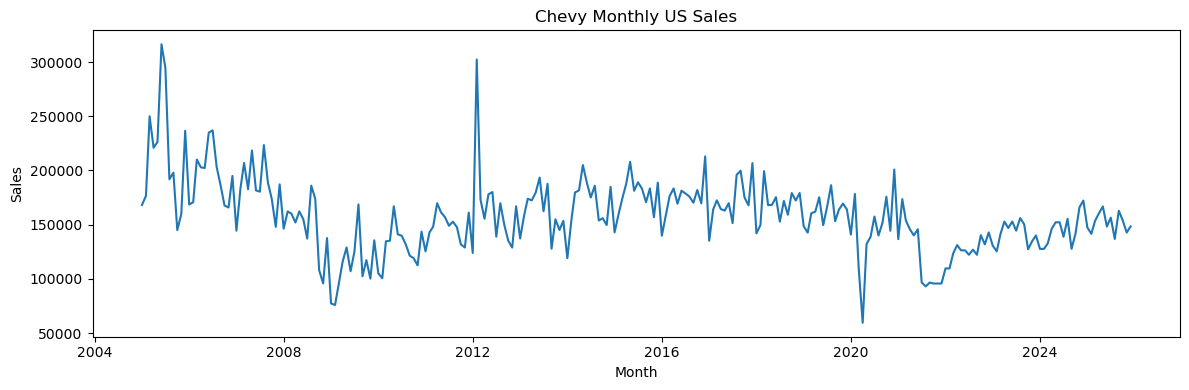

In [3]:
# Load data and reshape monthly columns into one time series
raw_df = pd.read_csv("Chevy_US_Data.csv")

month_cols = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_to_num = {month: i + 1 for i, month in enumerate(month_cols)}

sales_long = (
    raw_df[["Year", *month_cols]]
    .melt(id_vars="Year", value_vars=month_cols, var_name="Month", value_name="Sales")
)

sales_long["MonthNum"] = sales_long["Month"].map(month_to_num)
sales_long["Date"] = pd.to_datetime(
    dict(year=sales_long["Year"], month=sales_long["MonthNum"], day=1)
)

sales_ts = (
    sales_long.sort_values("Date")
    .set_index("Date")["Sales"]
    .astype(float)
    .asfreq("MS")
)

print(f"Observations: {len(sales_ts)}")
print(f"Date range: {sales_ts.index.min().date()} -> {sales_ts.index.max().date()}")

plt.figure(figsize=(12, 4))
plt.plot(sales_ts.index, sales_ts)
plt.title("Chevy Monthly US Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


In [4]:
# Chronological split (no shuffling for time series)
val_horizon = 12
test_horizon = 12

train = sales_ts.iloc[: -(val_horizon + test_horizon)]
val = sales_ts.iloc[-(val_horizon + test_horizon): -test_horizon]
test = sales_ts.iloc[-test_horizon:]

print(f"Train months: {len(train)} | {train.index.min().date()} -> {train.index.max().date()}")
print(f"Val months:   {len(val)} | {val.index.min().date()} -> {val.index.max().date()}")
print(f"Test months:  {len(test)} | {test.index.min().date()} -> {test.index.max().date()}")

# Small ARIMA grid search using validation RMSE
orders = list(itertools.product(range(0, 4), range(0, 3), range(0, 4)))

best_order = None
best_rmse = np.inf
order_scores = []

for order in orders:
    try:
        fitted = ARIMA(train, order=order).fit()
        val_forecast = fitted.forecast(steps=len(val))
        rmse_score = rmse(val.to_numpy(), val_forecast.to_numpy())
        order_scores.append((order, rmse_score))

        if rmse_score < best_rmse:
            best_rmse = rmse_score
            best_order = order
    except Exception:
        continue

if best_order is None:
    raise RuntimeError("No ARIMA model converged during grid search.")

print(f"Best ARIMA order: {best_order}")
print(f"Validation RMSE: {best_rmse:,.2f}")

print("\nTop 5 orders by validation RMSE:")
for order, score in sorted(order_scores, key=lambda x: x[1])[:5]:
    print(f"order={order} | RMSE={score:,.2f}")


Train months: 228 | 2005-01-01 -> 2023-12-01
Val months:   12 | 2024-01-01 -> 2024-12-01
Test months:  12 | 2025-01-01 -> 2025-12-01
Best ARIMA order: (3, 0, 3)
Validation RMSE: 12,467.12

Top 5 orders by validation RMSE:
order=(3, 0, 3) | RMSE=12,467.12
order=(3, 0, 0) | RMSE=12,919.70
order=(3, 0, 1) | RMSE=12,957.05
order=(3, 1, 1) | RMSE=12,961.65
order=(3, 1, 2) | RMSE=13,006.29


Test RMSE: 12,672.97
Test MAE:  10,035.33
Test MAPE: 6.91%


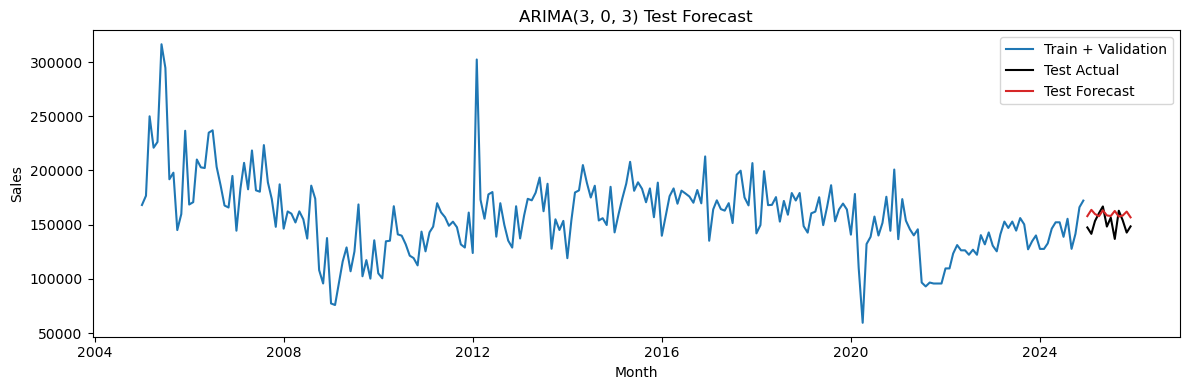


Next 12 months forecasted sales:
            Forecasted_Sales
2026-01-01            147023
2026-02-01            152080
2026-03-01            152564
2026-04-01            149553
2026-05-01            154327
2026-06-01            154468
2026-07-01            151333
2026-08-01            155905
2026-09-01            155781
2026-10-01            152588
2026-11-01            157016
2026-12-01            156681


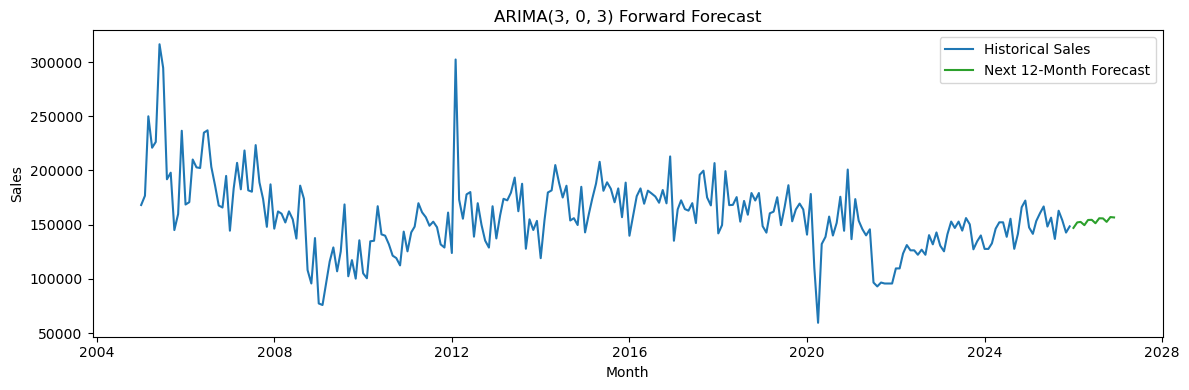

In [5]:
# Refit best order on train+val and evaluate on test
train_val = pd.concat([train, val])
final_model = ARIMA(train_val, order=best_order).fit()

test_forecast = final_model.forecast(steps=len(test))

test_rmse = rmse(test.to_numpy(), test_forecast.to_numpy())
test_mae = mae(test.to_numpy(), test_forecast.to_numpy())
test_mape = mape(test.to_numpy(), test_forecast.to_numpy())

print(f"Test RMSE: {test_rmse:,.2f}")
print(f"Test MAE:  {test_mae:,.2f}")
print(f"Test MAPE: {test_mape:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(train_val.index, train_val, label="Train + Validation")
plt.plot(test.index, test, label="Test Actual", color="black")
plt.plot(test.index, test_forecast, label="Test Forecast", color="tab:red")
plt.title(f"ARIMA{best_order} Test Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

# Fit on all available history and forecast the next 12 months
full_model = ARIMA(sales_ts, order=best_order).fit()
future_steps = 12
future_forecast = full_model.forecast(steps=future_steps)

future_index = pd.date_range(
    start=sales_ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=future_steps,
    freq="MS",
)
future_forecast.index = future_index

future_df = pd.DataFrame({"Forecasted_Sales": future_forecast.round(0).astype(int)})
print("\nNext 12 months forecasted sales:")
print(future_df)

plt.figure(figsize=(12, 4))
plt.plot(sales_ts.index, sales_ts, label="Historical Sales")
plt.plot(future_forecast.index, future_forecast, label="Next 12-Month Forecast", color="tab:green")
plt.title(f"ARIMA{best_order} Forward Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# For Capstone 6

rng = np.random.default_rng(42)
all_orders = list(itertools.product(range(0, 6), range(0, 3), range(0, 6))) # bigger search space
n_iter = 30 # number of random trials
idx = rng.choice(len(all_orders), size=min(n_iter, len(all_orders)), replace=False)
sampled_orders = [all_orders[i] for i in idx]

best_order, beset_rmse = None, np.inf
order_scores = []


for order in sampled_orders:
    try:
        fitted = ARIMA(train, order=order).fit() #Fit on training data only
        val_forecast = fitted.forecast(steps=len(val)) #Predict forecast on Validation data
        score = rmse(val.to_numpy(), val_forecast.to_numpy()) #Measure validation error
        order_scores.append((order, score))
        if score < best_rmse:
            best_rmse, best_order = score, order

    except Exception:
        continue


print("Best order:", best_order, "Val RMSE: ", best_rmse)
print("Top 5:", sorted(order_scores, key=lambda x: x[1])[:5])

In [6]:
# For Capstone 6

def make_lagged_df(series, n_lags): # Convert a time series into supervised data
    df = pd.DataFrame({"y": series})
    for lag in range(1, n_lags + 1):
        df[f"lag_{lag}"] = series.shift(lag)

    return df.dropna()

SEED = 42

param_dist = {
    "n_lags": range(3, 25),
    "alpha": np.logspace(-4, 2, 100) # L2 strength
} # Defines Hyperparameters to tune

sampler = list(ParameterSampler(param_dist, n_iter=40, random_state=SEED)) # Randomly samples 40 combos


train_end = train.index.max()
val_end = val.index.max()


best = {"rmse": np.inf}
for p in sampler:
    lagged = make_lagged_df(sales_ts, p["n_lags"])
    tr = lagged.loc[lagged.index <= train_end]
    va = lagged.loc[(lagged.index > train_end) & (lagged.index <= val_end)]
    if tr.empty or va.empty:
        continue

    X_tr, y_tr = tr.drop(columns="y"), tr["y"]
    X_va, y_va = va.drop(columns="y"), va["y"]

    model = Ridge(alpha=p["alpha"])
    model.fit(X_tr, y_tr)
    pred = model.predict(X_va)
    score = rmse(y_va.to_numpy(), pred)


    if score < best["rmse"]:
        best = {"rmse": score, "n_lags": p["n_lags"], "alpha": p["alpha"]}



print(best)

{'rmse': 13289.881946110228, 'n_lags': 6, 'alpha': np.float64(0.0003053855508833416)}
